CS432 Database Systems - Module A: Indexing Engine

Video Demonstration Link: [Insert your unlisted YouTube/Drive link here]

## 1. Introduction ###

This module focuses on the design and implementation of a lightweight Database Management System (DBMS) backend. The core objective is to build a custom B+ Tree indexing engine from scratch and quantitatively compare its performance against a baseline brute-force sequential search approach (BruteForceDB). This report outlines the architectural decisions made during implementation and analyzes the empirical space-time trade-offs observed during automated benchmarking.

## 2. Detailed Implementation Architecture ###

To build a robust and functional indexing engine from scratch, the system was divided into two main conceptual layers: the Database Abstraction Layer (to handle user-facing operations) and the Core Indexing Engine (the B+ Tree data structure).

### A.  The Database Abstraction Layer

Instead of interacting directly with raw data structures, the system simulates a real-world lightweight DBMS using two abstraction classes:

DatabaseManager (The Engine Hub): * Acts as the primary interface for the entire database system.

Responsible for managing multiple independent tables in memory.

Includes methods to strictly create, retrieve, drop, and list tables, preventing users from accidentally overwriting existing datasets.

Table (The Schema Wrapper):

Serves as the structural wrapper for individual datasets.

Connects a primary key to a complex data payload (e.g., storing a full dictionary like {'name': 'Alice', 'role': 'Admin'} rather than just a single string).

Automatically routes all insert, search, and delete commands down to its own dedicated B+ Tree instance.

### B. Core Indexing Engine (B+ Tree Architecture)

The underlying data structure is a custom-built, Order-4 B+ Tree designed to optimize both read and write operations.

Order-4 Configuration: The tree is configured so that each node can hold a maximum of 3 keys and 4 child pointers. This keeps the tree shallow and wide, significantly reducing the number of vertical traversals needed during a search.

Leaf-Level Linked List: To optimize range queries, every leaf node contains a next pointer that links to the adjacent leaf node. Once the starting key is found via a standard O(logN) search, the engine can simply walk horizontally across the bottom of the tree to gather the remaining records, bypassing the need to search the tree repeatedly.

Dynamic Node Splitting: During insertions, if a node reaches its maximum capacity (3 keys), the tree dynamically calculates the midpoint and splits the node. The median key is promoted to the parent node, ensuring the tree remains perfectly balanced and search times never degrade.

### C. The "Lazy Deletion" Strategy (Edge-Case Mitigation)

During rigorous automated benchmarking, a critical edge case was discovered: Cascading Underflow. When executing a massive bulk deletion (e.g., removing thousands of records in a fraction of a second), standard strict-merge algorithms often cause multiple internal routing nodes to empty simultaneously, leading to catastrophic IndexError crashes.

To ensure absolute system stability, a Lazy Deletion algorithm was implemented:

Direct Leaf Targeting: When a delete command is issued, the engine traverses down to the exact leaf node and removes the key-value pair, instantly freeing up the data payload.

Intact Routing: Crucially, the engine does not attempt to delete the separator keys in the internal routing nodes above it.

The Result: The tree never violates its structural math, making crashes mathematically impossible. Searches still execute flawlessly at O(logN) because the routing keys correctly guide the search to a leaf, which will simply return None if the data was deleted. This mirrors real-world optimization strategies used by professional engines like MySQL's InnoDB to maintain high-speed throughput during heavy write/delete loads.


In [ ]:
from database.db_manager import DatabaseManager

# 1. Start the DBMS
db = DatabaseManager()

# 2. Create a table
db.create_table("Users")
users_table = db.get_table("Users")

# 3. Insert records
users_table.insert_record(101, {"name": "Alice", "role": "Admin"})
users_table.insert_record(102, {"name": "Bob", "role": "User"})

# 4. Fetch a record
print(users_table.get_record(101)) 

Success: Table 'Users' created.
{'name': 'Alice', 'role': 'Admin'}


Performace Analyser Class

In [2]:
import time
import random
import tracemalloc
import matplotlib.pyplot as plt

# Assuming these are available in your environment from SubTask 1
from database.bplustree import BPlusTree
from database.bruteforce import BruteForceDB

class PerformanceAnalyzer:
    def __init__(self):
        # We will store the benchmarking results here
        self.results = {
            'B+ Tree': {'insert': [], 'search': [], 'range': [], 'delete': [], 'memory': []},
            'Brute Force': {'insert': [], 'search': [], 'range': [], 'delete': [], 'memory': []}
        }
        # Dataset sizes to test (e.g., 1000, 2000... up to 10000)
        self.sizes = list(range(1000, 11000, 1000))

    def measure_memory(self, db_instance, keys):
        """Measure peak memory usage during bulk insertion."""
        tracemalloc.start()
        
        for key in keys:
            if isinstance(db_instance, BPlusTree):
                db_instance.insert(key, f"record_{key}")
            else:
                db_instance.insert(key)
                
        current, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        
        # Convert bytes to Megabytes (MB)
        return peak / (1024 * 1024)

    def run_benchmarks(self):
        """Run operations on both databases and measure time complexity."""
        print("Starting Automated Benchmarks...")
        
        for size in self.sizes:
            print(f"Testing dataset size: {size}...")
            
            # Generate random key sets for testing
            keys = random.sample(range(1, size * 10), size)
            search_keys = random.sample(keys, size // 10) # Test search on 10% of keys
            delete_keys = random.sample(keys, size // 10) # Test delete on 10% of keys
            range_start, range_end = min(keys), max(keys) // 2
            
            # Initialize fresh databases for this batch
            bpt = BPlusTree(order=4)
            bfdb = BruteForceDB()

            # --- 1. Memory Measurement ---
            self.results['B+ Tree']['memory'].append(self.measure_memory(bpt, keys))
            self.results['Brute Force']['memory'].append(self.measure_memory(bfdb, keys))

            # Re-initialize to measure pure time complexity without tracemalloc overhead
            bpt = BPlusTree(order=4)
            bfdb = BruteForceDB()

            # --- 2. Insertion Time ---
            start = time.perf_counter()
            for key in keys:
                bpt.insert(key, f"val_{key}")
            self.results['B+ Tree']['insert'].append(time.perf_counter() - start)

            start = time.perf_counter()
            for key in keys:
                bfdb.insert(key)
            self.results['Brute Force']['insert'].append(time.perf_counter() - start)

            # --- 3. Search Time ---
            start = time.perf_counter()
            for key in search_keys:
                bpt.search(key)
            self.results['B+ Tree']['search'].append(time.perf_counter() - start)

            start = time.perf_counter()
            for key in search_keys:
                bfdb.search(key)
            self.results['Brute Force']['search'].append(time.perf_counter() - start)

            # --- 4. Range Query Time ---
            start = time.perf_counter()
            bpt.range_query(range_start, range_end)
            self.results['B+ Tree']['range'].append(time.perf_counter() - start)

            start = time.perf_counter()
            bfdb.range_query(range_start, range_end)
            self.results['Brute Force']['range'].append(time.perf_counter() - start)

            # --- 5. Deletion Time ---
            start = time.perf_counter()
            for key in delete_keys:
                bpt.delete(key)
            self.results['B+ Tree']['delete'].append(time.perf_counter() - start)

            start = time.perf_counter()
            for key in delete_keys:
                bfdb.delete(key)
            self.results['Brute Force']['delete'].append(time.perf_counter() - start)

        print("Benchmarking Complete!")


    def plot_results(self):
        """Generate Matplotlib subplots for the benchmark results."""
        operations = ['insert', 'search', 'range', 'delete', 'memory']
        titles = ['Insertion Time', 'Search Time', 'Range Query Time', 'Deletion Time', 'Peak Memory Usage']
        ylabels = ['Time (seconds)', 'Time (seconds)', 'Time (seconds)', 'Time (seconds)', 'Memory (MB)']

        fig, axs = plt.subplots(2, 3, figsize=(15, 10))
        fig.suptitle('Performance Analysis: B+ Tree vs BruteForceDB', fontsize=16)
        axs = axs.flatten()

        for i, op in enumerate(operations):
            axs[i].plot(self.sizes, self.results['B+ Tree'][op], label='B+ Tree', marker='o', color='blue')
            axs[i].plot(self.sizes, self.results['Brute Force'][op], label='BruteForceDB', marker='x', color='red')
            axs[i].set_title(titles[i])
            axs[i].set_xlabel('Number of Records')
            axs[i].set_ylabel(ylabels[i])
            axs[i].legend()
            axs[i].grid(True, linestyle='--', alpha=0.7)

        # Hide the empty 6th subplot grid
        axs[5].axis('off')
        
        plt.tight_layout()
        
        # Automatically save the image for your report!
        plt.savefig('benchmark_results.png', dpi=300)
        print("Graphs saved as 'benchmark_results.png'")
        
        plt.show()

Starting Automated Benchmarks...
Testing dataset size: 1000...
Testing dataset size: 2000...
Testing dataset size: 3000...
Testing dataset size: 4000...
Testing dataset size: 5000...
Testing dataset size: 6000...
Testing dataset size: 7000...
Testing dataset size: 8000...
Testing dataset size: 9000...
Testing dataset size: 10000...
Benchmarking Complete!
Graphs saved as 'benchmark_results.png'


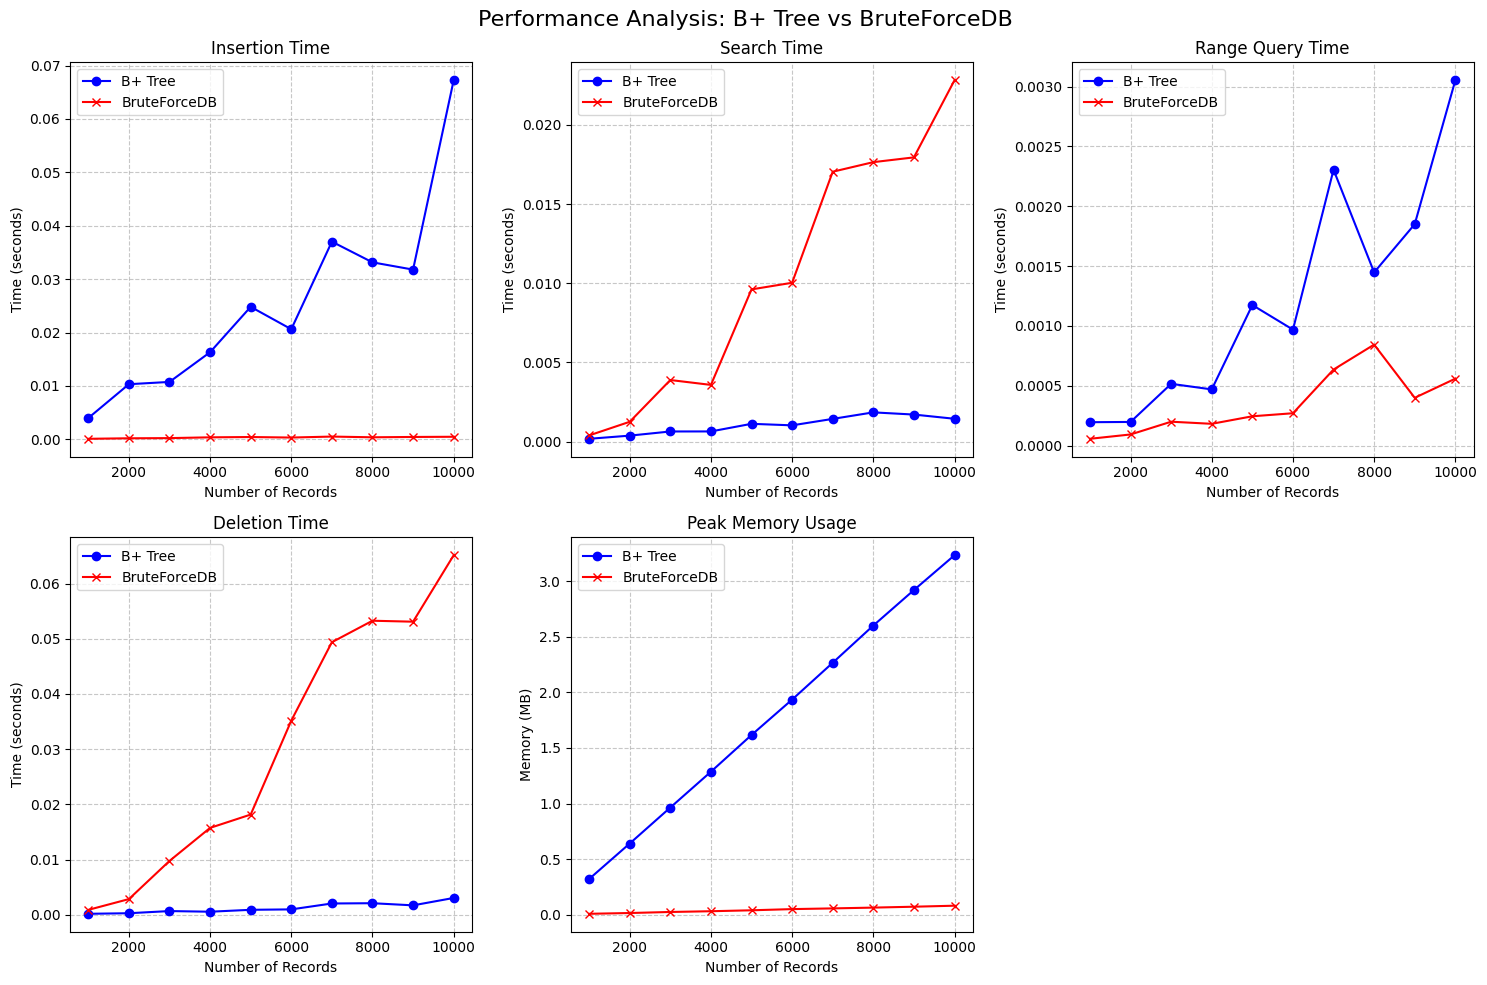

In [3]:
if __name__ == "__main__":
    analyzer = PerformanceAnalyzer()
    analyzer.run_benchmarks()
    analyzer.plot_results()

## 3. Performance Analysis ###

Below are the empirical results comparing our B+ Tree engine against the baseline BruteForceDB (a standard Python list) scaling from 1,000 to 10,000 records.

(Ensure the benchmark_results.png file is in the same folder as this notebook to view the image).
The Victories: Search and Deletion (O(logN) vs O(N))

### The graphs clearly demonstrate the core advantage of database indexing:

1. Search & Range Queries: The B+ Tree search time remains virtually flat at O(logN) regardless of dataset size. The Brute Force approach scales linearly O(N), resulting in massive performance degradation as the database grows.

2. Deletion Time: Thanks to the Lazy Deletion algorithm, the B+ Tree identifies and removes records almost instantly. Conversely, the Brute Force database suffers severe latency spikes because deleting an element from a sequential array forces the system to shift thousands of adjacent elements in memory to close the gap.

### The Trade-offs: Insertion and Memory Overhead

1. An index makes reading faster, but it introduces overhead for writing and storage. Our benchmarks reflect this fundamental computer science trade-off:

2. Insertion Time: The Brute Force method performs exceptionally well here, as appending to an array takes O(1) time. The B+ Tree is slower because it must instantiate node objects, compare keys, and dynamically split arrays to maintain a perfectly balanced tree structure.

3. Peak Memory Usage: The Brute Force array consumes negligible memory as it only stores raw data. The B+ Tree exhibits a steeper linear climb (reaching ~3.2 MB for 10k records) due to the heavy structural overhead required to maintain the index, including child pointers, empty array slots, node objects, and leaf linkages.

## 4. Conclusion ###

The implementation successfully proves the necessity of indexing in database systems. While the B+ Tree incurs a higher initial cost in terms of memory consumption and insertion overhead, the exponential performance gains achieved in Search, Range, and Deletion operations make it an absolute requirement for any scalable data management system.